In [9]:
from sklearn import datasets
import numpy as np
from mlxtend.plotting import plot_decision_regions
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

<h4> Zadanie1 (1 pkt): Rozważ dane Medical‑Abstracts‑TC‑Corpus — zbiór abstraktów medycznych z 5 klasami (nowotwory, choroby układu pokarmowego, nerwowego, sercowo‑naczyniowego i „ogólne stany patologiczne”). W oparciu o metodę SVM zbuduj klasyfikator na reprezentacjach TF-IDF tych abstraktów. Poniżej pare uwag:
    
- zbiory: treningowy i testowy są już wydzielone
- potestuj różne hiperparametry (zarówno dla SVM jak i TF - IDF, np. max_features)
- finalny raport klasyfikacji na zbiorze testowym powinien wynosić co najmniej 50 \% (a najlepiej więcej) dla f1-score dla każdej kategorii.
- być może przydatne będzie dogenerowanie nowych danych na podstawie istniejących przykładów (balansowanie danych)

In [10]:
import pandas as pd

df = pd.read_csv("medical_tc_train.csv")
print(df.head())

   condition_label                                   medical_abstract
0                5  Tissue changes around loose prostheses. A cani...
1                1  Neuropeptide Y and neuron-specific enolase lev...
2                2  Sexually transmitted diseases of the colon, re...
3                1  Lipolytic factors associated with murine and h...
4                3  Does carotid restenosis predict an increased r...


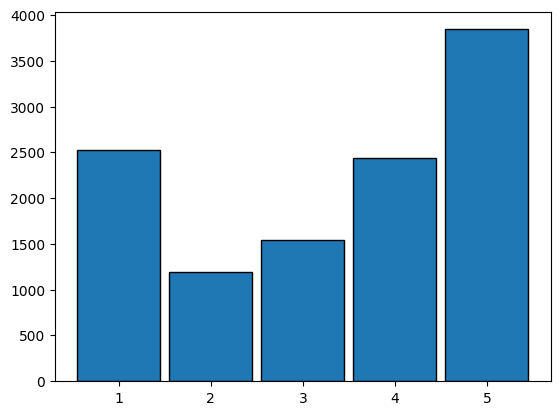

In [11]:
plt.hist(df['condition_label'], bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5], align='mid', rwidth=0.9, edgecolor='black')
plt.xticks([1, 2, 3, 4, 5]) 
plt.show()

In [12]:
X_train = df["medical_abstract"]
y_train = df['condition_label']

In [13]:
# Dane testowe
test_df = pd.read_csv("medical_tc_test.csv")
X_test = test_df["medical_abstract"]
y_test = test_df["condition_label"]

In [14]:
# Tworzenie wektorów ze słów
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# PCA 
pca_for_text = TruncatedSVD(random_state=42)
X_train_pca = pca_for_text.fit_transform(X_train_tfidf)
X_test_pca = pca_for_text.transform(X_test_tfidf)

In [16]:
from sklearn.svm import SVC
svc = SVC(kernel="rbf", class_weight="balanced", random_state=0)
param_grid = {
    "C": [1, 5, 10, 50],                 
    "gamma": [0.0001, 0.001, 0.01, "scale"] 
}

grid = GridSearchCV(svc, param_grid)
grid = grid.fit(X_train_pca, y_train)

In [ ]:
print("Najlepsze parametry:", grid.best_params_)

<h4> Zadanie2 (1+2 pkt): Rozważ sekwencje intronów i eksonów z ludzkiego chromosomu 1. 

- Wydziel zbiór treningowy i testowy
- Zaproponuj reprezentacje dla tych sekwencji (np. częstości wybranych k-merów, inne pomysły mile widziane), zastanów się czy warto normalizować/standaryzować dane
- Zbuduj klasyfikator w oparciu o SVM, na zbiorze testowym f1-score dla każdej kategorii powinno wynosić co najmniej 90 \%
- Spróbuj zinterpretować zbudowany model - wksaż które cechy sekwencji najbardziej decydują o tym, że dana sekwencja jest eksonem/intronem - np. częstości wybranych k-merów. Możesz wykorzystać algorytm RFE (https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.RFE.html).

Druga część zadania (stanowiąca rozszerzenie pierwszej części) będzie polegać na stworzeniu modelu (w oparciu o SVM) który dla sekwencji składajacej się z intronów oraz eksonów rozpozna miejsca zmiany typu sekwencji genu - złożonej zarówno z intronów jak i eksonów EEEEEIIIIIIEEEEEIIII - czyli powie nam gdzie kończą/zaczynają się eksony. W tym przypadku możesz np. poruszać się oknem o zadanej długości i zastosować model z części I - być może warto narysować odpowiedni wykres. Inne pomysły bardzo mile widziane! (liczę na waszą kreatywność :)). Wyznaczenie dokładnego miejsca zmiany może być trudne, jako kryterium przyjmij, np. +-kilkanaście/kilkadziesiąt pozycji jako próg tolerancji. Zaproponuj odpowiednią fukcję kosztu/miarę oceny.

- To zadanie (zadanie2) proszę opracować także w formie raportu - 1 strona pdf. 

In [21]:
def read_fasta(filename):
    #Odczytuje sekwencje z pliku.
    seqs = []
    with open(filename, 'r') as f:
        seq = ""
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                if seq:
                    seqs.append(seq)
                    seq = ""
            else:
                seq += line
        if seq:
            seqs.append(seq)
    return seqs

def get_kmer_freq(seq, k=4):
    # Częstość występowania k-merów w sekwencji.
    kmers = [seq[i:i+k] for i in range(len(seq)-k+1)]
    unique_kmers = set(kmers)
    freqs = {kmer: len([x for x in kmers if x == kmer]) / len(kmers) for kmer in unique_kmers}
    
    return freqs

In [22]:
# Wczytanie danych
exons = read_fasta('exons.txt')
introns = read_fasta('introns.txt')

print(f"Liczba eksonów: {len(exons)}")
print(f"Liczba intronów: {len(introns)}")

# Ekstrakcja 4-merów
k = 4
exon_freqs = [get_kmer_freq(seq, k) for seq in exons]
intron_freqs = [get_kmer_freq(seq, k) for seq in introns]

#  DataFrames
df_exons = pd.DataFrame(exon_freqs).fillna(0)
df_exons['label'] = 1 # 1 dla eksonu

df_introns = pd.DataFrame(intron_freqs).fillna(0)
df_introns['label'] = 0 # 0 dla intronu

# Uzupełnianie brakujących k-merów zerami
df = pd.concat([df_exons, df_introns], axis=0).fillna(0)

X = df.drop('label', axis=1)
y = df['label']

# Standaryzacja 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)


Liczba eksonów: 400
Liczba intronów: 261


In [26]:
# SVM
from sklearn.svm import SVC, LinearSVC
from sklearn.feature_selection import RFE

svm = LinearSVC(random_state=42, max_iter=10000)
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['Intron (0)', 'Ekson (1)']))

# Interpretacja cech (RFE)
rfe = RFE(estimator=LinearSVC(random_state=42, max_iter=10000), n_features_to_select=10)
rfe.fit(X_train, y_train)

feature_names = X.columns
selected_features = [feature_names[i] for i, selected in enumerate(rfe.support_) if selected]
print("Top 10 najważniejszych 4-merów:")
print(selected_features)

              precision    recall  f1-score   support

  Intron (0)       0.90      1.00      0.95        53
   Ekson (1)       1.00      0.93      0.96        80

    accuracy                           0.95       133
   macro avg       0.95      0.96      0.95       133
weighted avg       0.96      0.95      0.96       133

Top 10 najważniejszych 4-merów:
['ATGA', 'ACCA', 'CAAG', 'AGGG', 'AGCG', 'TTTA', 'TTCA', 'TTTT', 'TACG', 'TAAG']


<h5> Detekcja miejsc zmian

In [28]:
# Sztuczna sekwencja
test_seq = exons[0][:200] + introns[0][:200] + exons[1][:200] + introns[1][:200]

svm_prob = SVC(kernel='linear', probability=True, random_state=42)
svm_prob.fit(X_train, y_train)

window_size = 50
step = 5
probs = []
positions = []

# Przesuwanie okna
for i in range(0, len(test_seq) - window_size + 1, step):
    window_seq = test_seq[i:i+window_size]

    kmers = [window_seq[j:j+k] for j in range(len(window_seq)-k+1)]
    freqs = {kmer: len([x for x in kmers if x == kmer]) / len(kmers) for kmer in X.columns}
    
    x_win = pd.DataFrame([freqs]).reindex(columns=X.columns, fill_value=0)
    x_win_scaled = scaler.transform(x_win)
    
    # Prawdopodobieństwo bycia eksonem
    prob_exon = svm_prob.predict_proba(x_win_scaled)[0][1] 
    
    probs.append(prob_exon)
    positions.append(i + window_size // 2)

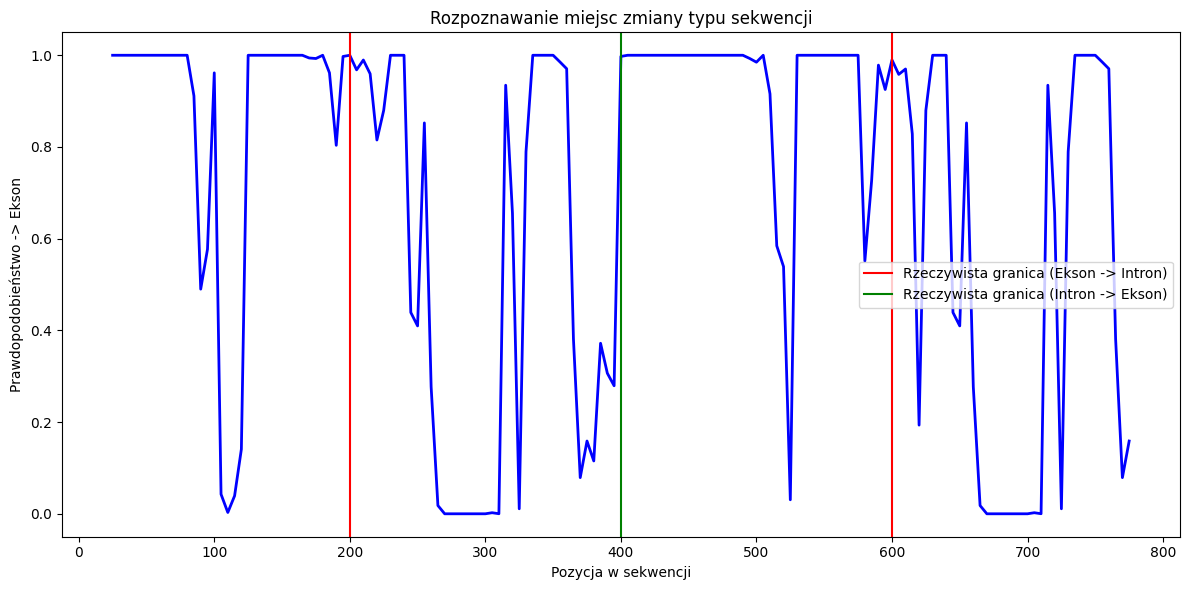

In [33]:
# Wykres
plt.figure(figsize=(12, 6))
plt.plot(positions, probs, color='blue', linewidth=2)

# Granice
plt.axvline(x=200, color='red', label='Rzeczywista granica (Ekson -> Intron)')
plt.axvline(x=400, color='green', label='Rzeczywista granica (Intron -> Ekson)')
plt.axvline(x=600, color='red')

plt.xlabel('Pozycja w sekwencji')
plt.ylabel('Prawdopodobieństwo -> Ekson')
plt.title('Rozpoznawanie miejsc zmiany typu sekwencji')
plt.legend()
plt.tight_layout()
plt.show()